In [3]:
import sys
sys.path.append('../')

from mingpt.model import GPT
from mingpt.trainer import Trainer
import torch
from torch.utils.data import Dataset
import numpy as np
import torch
import torch.nn.functional as F
from mingpt.model import GPT
import pickle
import matplotlib.pyplot as plt

# Model functions

In [4]:
class ModelDataset(Dataset):
    def __init__(self, p, n=10, num_samples=10000):
        self.n = n
        self.block_size = n - 1
        # pre-generate all sequences at init
        self.data = []
        for _ in range(num_samples):
            seq = torch.bernoulli(torch.full((n,), p)).long()
            x = seq[:-1].clone()
            y = seq[1:].clone()
            self.data.append((x, y))

    def get_block_size(self):
        return self.block_size

    def __getitem__(self, idx):
        return self.data[idx]  # returns fixed pre-generated sequence

    def __len__(self):
        return len(self.data)

In [5]:
# Model configure

def model_configure(dataset, iters=1000, learn_rate=1e-4):
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = dataset.get_block_size()
    model = GPT(model_config)

    device = 'mps'
    model = model.to(device)

    train_config = Trainer.get_default_config()
    train_config.learning_rate = learn_rate
    train_config.max_iters = iters
    train_config.num_workers = 0
    train_config.device = 'mps'
    trainer = Trainer(train_config, model, dataset)
    return model, trainer

def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter_dt {trainer.iter_num}; iter {trainer.iter_num}: train loss {trainer.loss.item():.5f}")

def train_run(model, trainer, output_name):
    save_dir = model_save_folder + output_name
    print(f'Saving to {save_dir}')
    trainer.set_callback('on_batch_end', batch_end_callback)
    trainer.run()
    torch.save({
        'state_dict': model.state_dict(),
        'block_size': model.block_size
    }, save_dir)
    print(f'Saved to {save_dir}')

# Experiment infrastructure

In [6]:
experiment_save_folder = '../experiments/'
N_values = [10, 25, 50, 100, 200, 499]

In [7]:

def iid_generate(p_dict, N):
    p0 = p_dict[0]
    p1 = p_dict[1]
    return np.random.choice([0,1], size=N, p=[p0, p1])

def generate_bin_pmf():
    p = np.random.rand()
    dict_out = {
        0: p,
        1: 1-p
    }
    return dict_out

def convert_sample_to_pmf(sample):
    values, counts = np.unique(sample, return_counts=True)
    probs = counts/counts.sum()
    return dict(zip(values, probs))

def entropy_calc(pmf):
    pmf = clean_pmf(pmf)
    pmf_array = np.asarray(list(pmf.values()))
    return -np.sum(pmf_array * np.log2(pmf_array))

def clean_pmf(pmf):
    return {k: v for k, v in pmf.items() if v > 0.0}

In [8]:
def sequential_universal_source_coding(seq, p_array = None):
    total_bits = 0
    k = 0
    i = 0

    for bit in seq:
        if p_array is not None:
            p1 = p_array[i]
        else:
            p1 = (k+1) / (i+2)
        p0 = 1-p1

        if bit == 1:
            total_bits += -np.log2(p1)
        else:
            total_bits += -np.log2(p0)
        k += bit
        i += 1

    bits_per_symbol = total_bits / len(seq)
    return bits_per_symbol

In [9]:

# generate an array of probabilities given a bit sequence

def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    sequence=torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _ = model(sequence)  # [1, T, vocab_size]
        # convert to probabilities
        probs = F.softmax(logits, dim=-1)  # [1, T, vocab_size]
        # extract probability of token=1 at each timestep
        p_array = [0.5] + probs[0, :-1, 1].tolist()
    
    return p_array

In [10]:
def load_model(model_dir):
    checkpoint = torch.load(model_dir, map_location='cpu')
    block_size = checkpoint['block_size']
    
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = block_size
    
    model = GPT(model_config)
    model.load_state_dict(checkpoint['state_dict'])
    model = model.to('mps')
    model.eval()
    return model

In [11]:
# Transformer vs Laplace prior quality at small N

def run_experiment(model, p_values, N_values, output_file, n_trials=100, device='mps'):
    """
    For each (p, N) pair, run n_trials with identical sequences for both methods.
    Returns nested dict: results[p][N] = {'laplace': (mean, std), 'transformer': (mean, std)}
    """
    all_results = {}
    save_dir = experiment_save_folder + output_file
    print(f'Saving to {save_dir}')

    for p_true in p_values:
        print(f"\nRunning p={p_true}")
        p_dict = {0: 1 - p_true, 1: p_true}
        all_results[p_true] = {}

        for N in N_values:
            laplace_bps_trials = []
            transformer_bps_trials = []

            for trial in range(n_trials):
                # Same sequence for both methods
                seq = iid_generate(p_dict, N)

                # Laplace
                bps_lap = sequential_universal_source_coding(seq)
                laplace_bps_trials.append(bps_lap)

                # Transformer
                p_array = transformer_p_array(seq, model, device=device)
                bps_trans = sequential_universal_source_coding(seq, p_array=p_array)
                transformer_bps_trials.append(bps_trans)

            all_results[p_true][N] = {
                'laplace': (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
                'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
                'entropy': entropy_calc({p_true: p_true, 1-p_true: 1-p_true})
            }
            print(f"  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}")

    with open(save_dir, 'wb') as f:
        pickle.dump(all_results, f)

    print(f'Saved experiment to {save_dir}')




In [ ]:
num_samples_sweep = [10, 25, 50, 75, 100, 150, 200, 300, 500, 1000, 5000, 10000]
seq_samples = 500
iters = 1000
learn_rate = 1e-4
model_save_folder = '../models/'
p_true = 0.3
N = 100
n_trials = 500
iters = 500
entropy = entropy_calc({p_true: p_true, 1-p_true: 1-p_true})

# Laplace baseline
laplace_bps_trials = []
for _ in range(n_trials):
    seq = iid_generate({0: 1-p_true, 1: p_true}, N)
    laplace_bps_trials.append(sequential_universal_source_coding(seq))
laplace_redundancy = np.mean(laplace_bps_trials) - entropy

# Transformer sweep
benchmark_results = {}
for num_samples in num_samples_sweep:
    dataset = ModelDataset(p=p_true, n=seq_samples, num_samples=num_samples)
    model, trainer = model_configure(dataset, iters=iters)
    train_run(model, trainer, f'benchmark_{num_samples}.pt')
    
    bps_trials = []
    for _ in range(n_trials):
        seq = iid_generate({0: 1-p_true, 1: p_true}, N)
        p_array = transformer_p_array(seq, model)
        bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array))
    
    benchmark_results[num_samples] = np.mean(bps_trials) - entropy
    print(f"num_samples={num_samples}: transformer_redundancy={benchmark_results[num_samples]:.4f}, laplace_redundancy={laplace_redundancy:.4f}")

print(f"\nLaplace redundancy: {laplace_redundancy:.4f}")
print(f"Benchmark results: {benchmark_results}")

with open('../experiments/benchmark_results.pkl', 'wb') as f:
    pickle.dump({'transformer': benchmark_results, 'laplace': laplace_redundancy}, f)

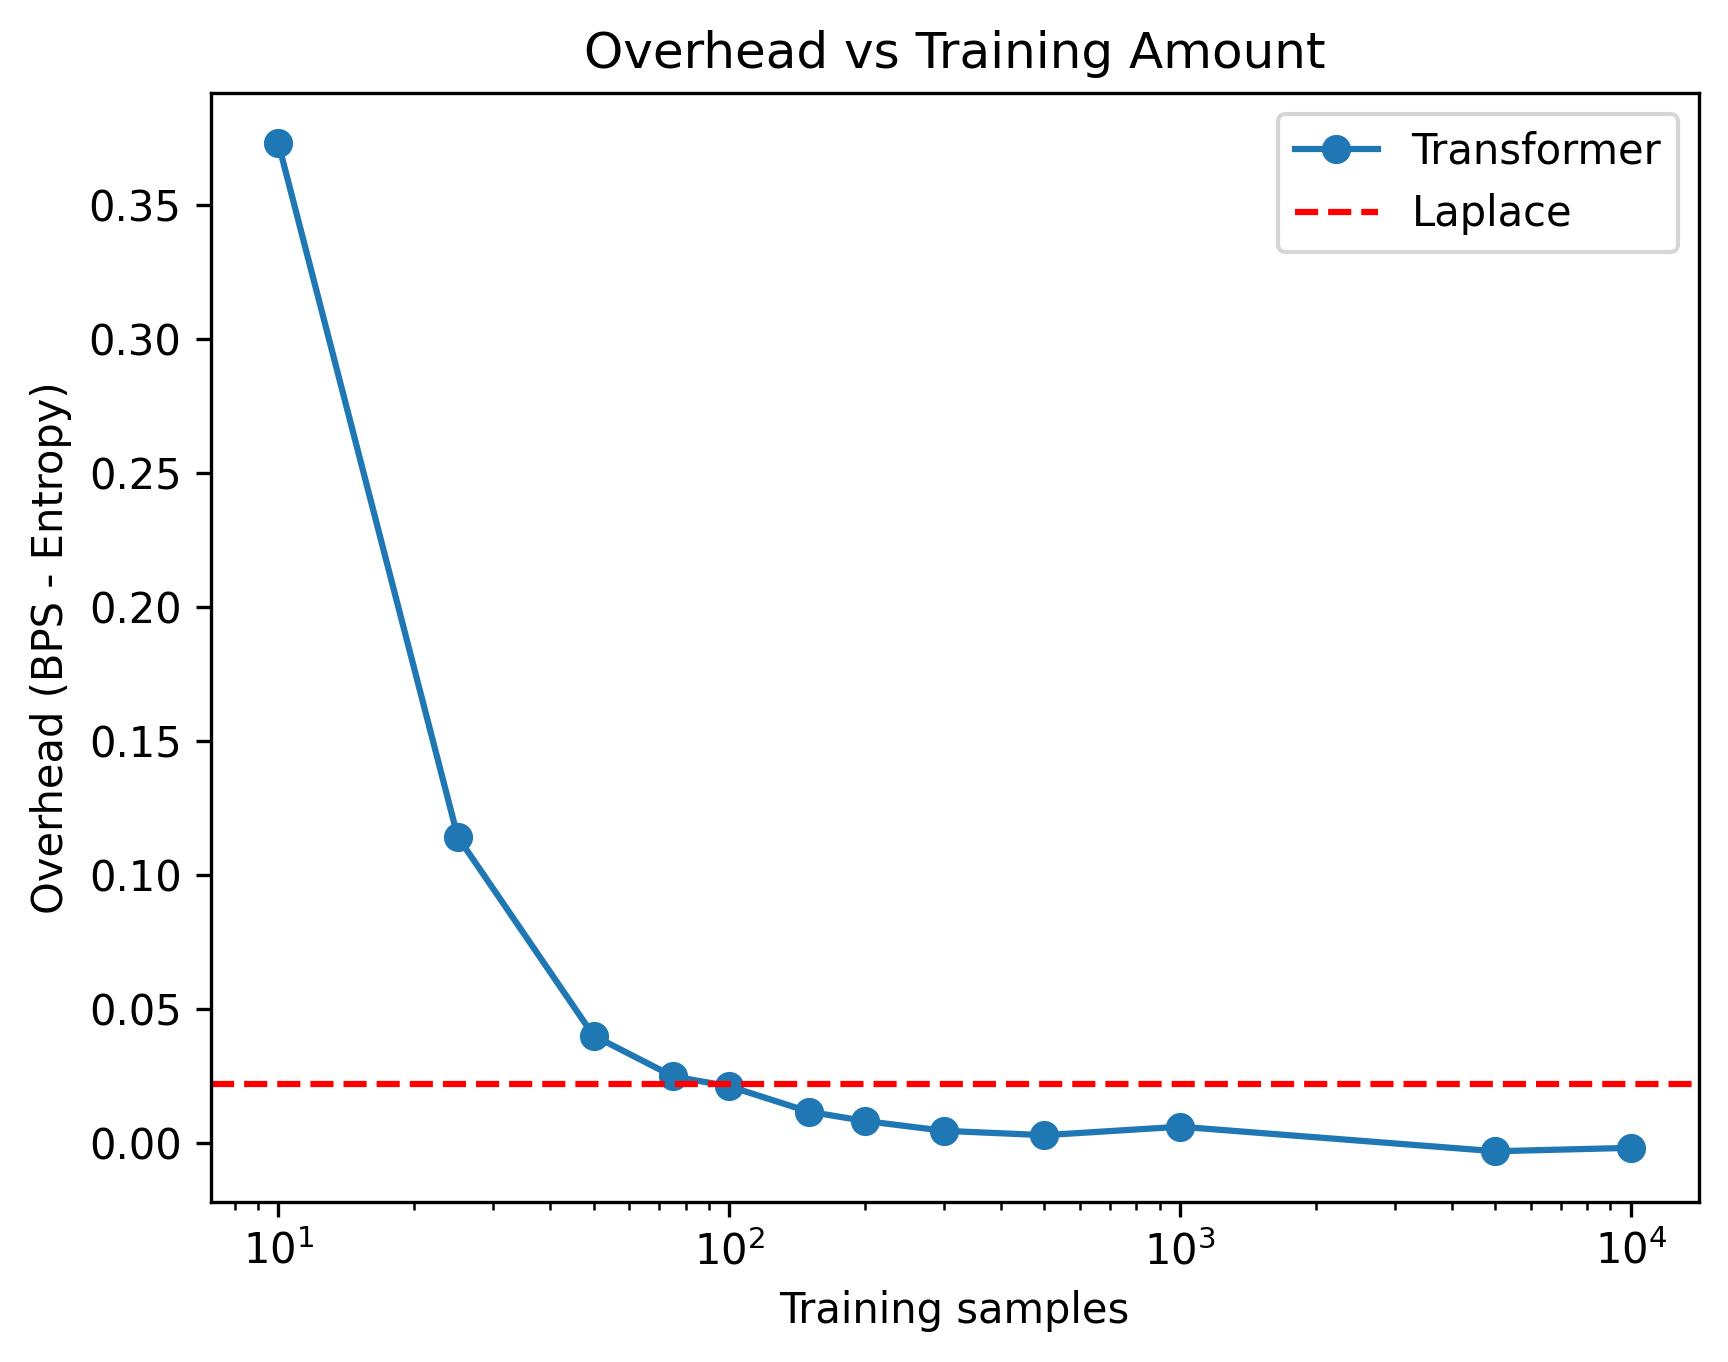

In [13]:
with open('../experiments/benchmark_results.pkl', 'rb') as f:
    data = pickle.load(f)

n_vals = list(data['transformer'].keys())
redundancies = list(data['transformer'].values())

plt.figure(dpi=300)
plt.plot(n_vals, redundancies, marker='o', label='Transformer')
plt.axhline(y=data['laplace'], color='r', linestyle='--', label='Laplace')
plt.xscale('log')
plt.xlabel('Training samples')
plt.ylabel('Overhead (BPS - Entropy)')
plt.title('Overhead vs Training Amount')
plt.legend()
plt.show()